# Machine Learning Tutorial 11 - Support Vector Machine

Support vector machine __(SVM)__ is a popular classification algorithm. This tutorial covers some theory first and then goes over python coding to solve __iris flower classification__ problem using __svm and sklearn__ library. We also cover different parameters such as __gamma, regularization__ and how to fine tune __svm classifier__ using these parameters.

Code: https://github.com/codebasics/py/blob/master/ML/10_svm/10_svm.ipynb

Credit: https://www.youtube.com/watch?v=FB5EdxAGxQg&list=PLeo1K3hjS3uvCeTYTeyfe0-rN5r8zn9rw&index=11

#### Owner: Codebasics

# Image classification, Image segmentation, High Protein Classification
# Digital Character Recognition



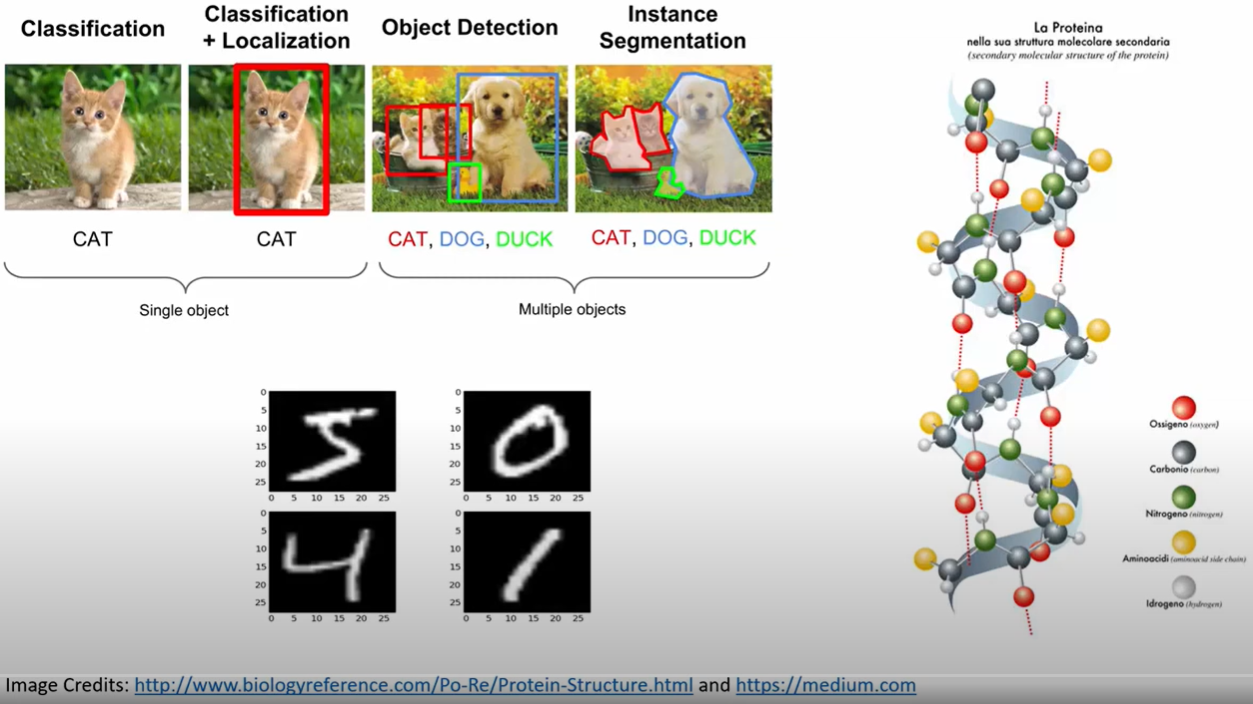

# Iris flower classification using sklearn

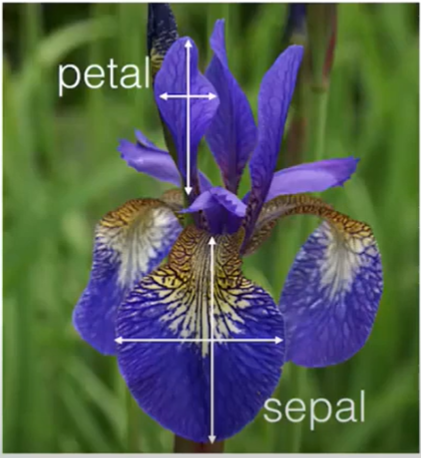

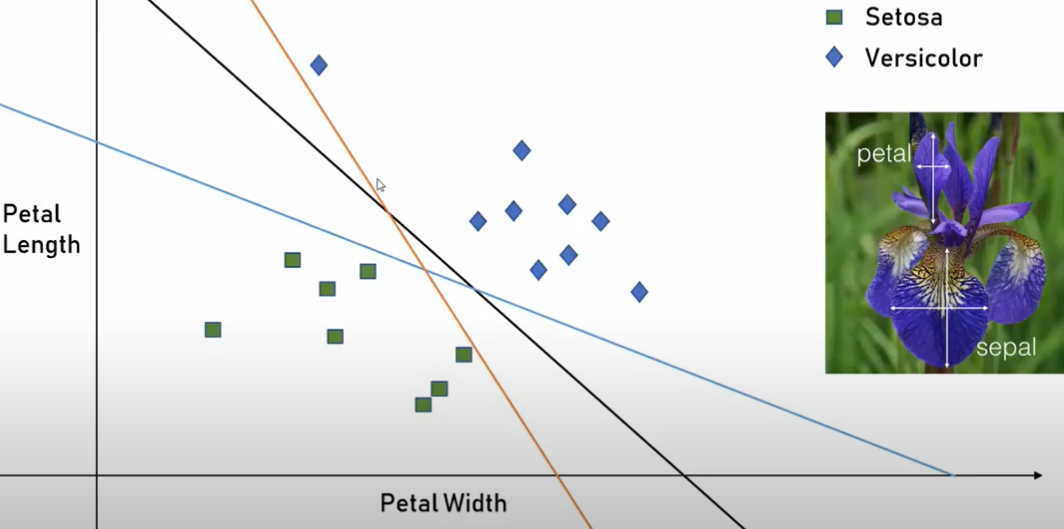

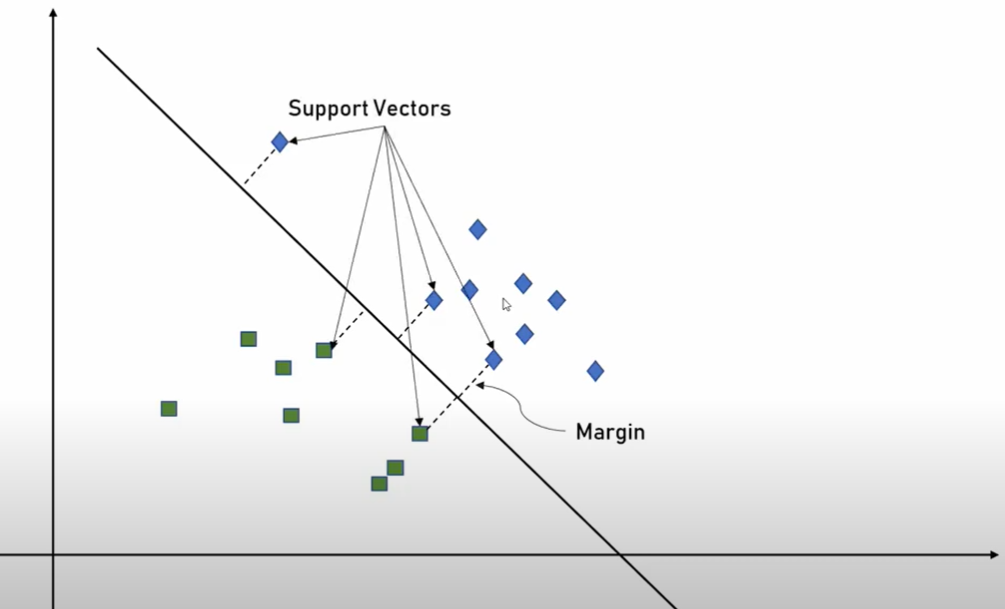

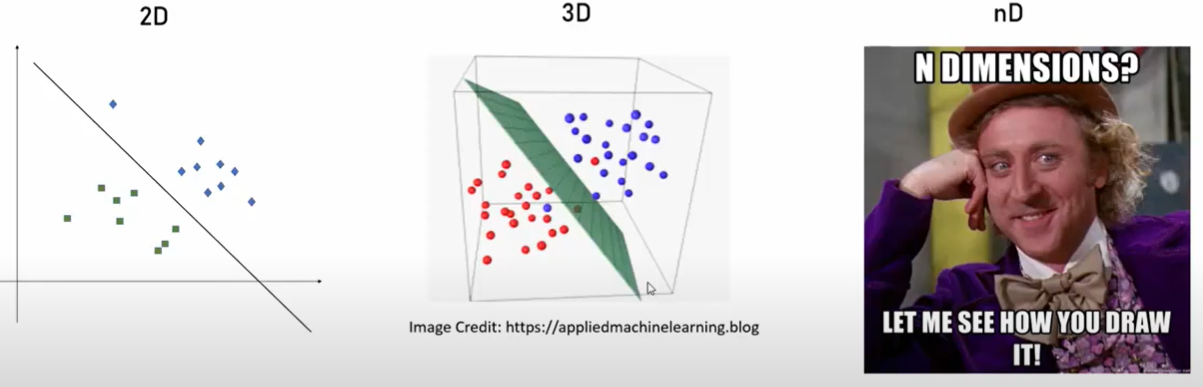

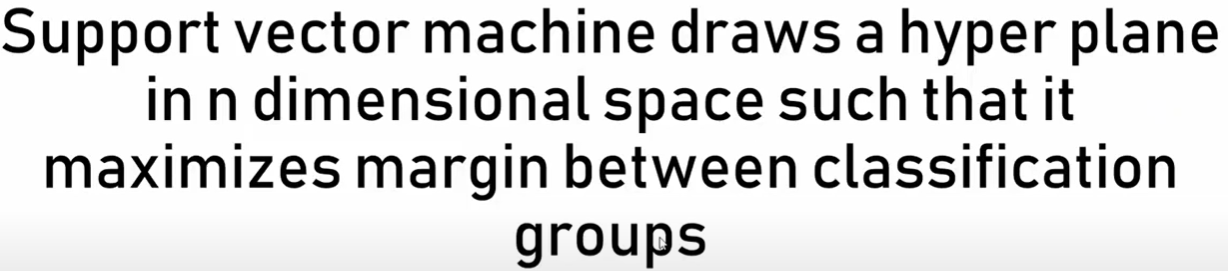

# Gamma and Regularization

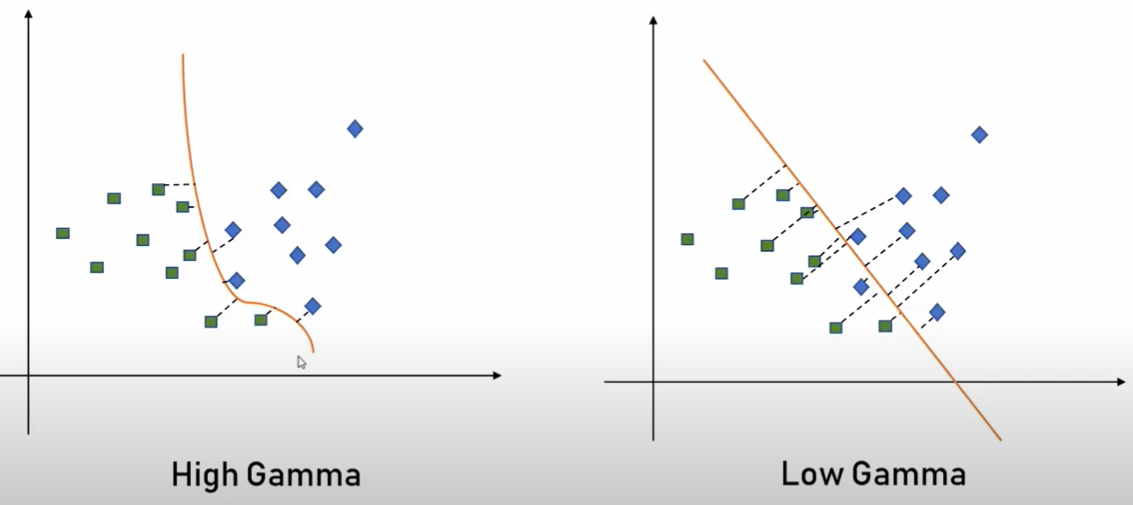

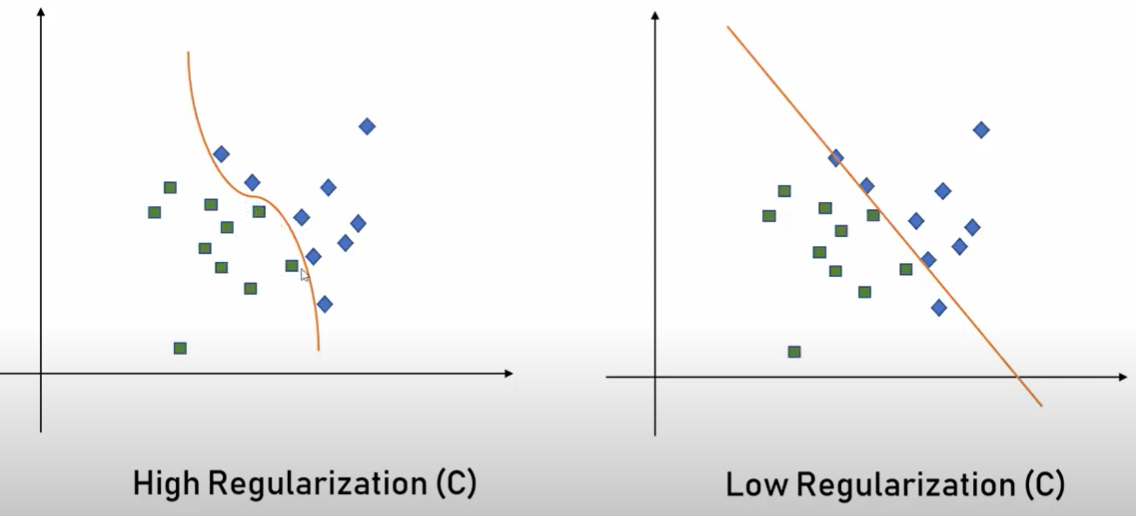

# Kernel

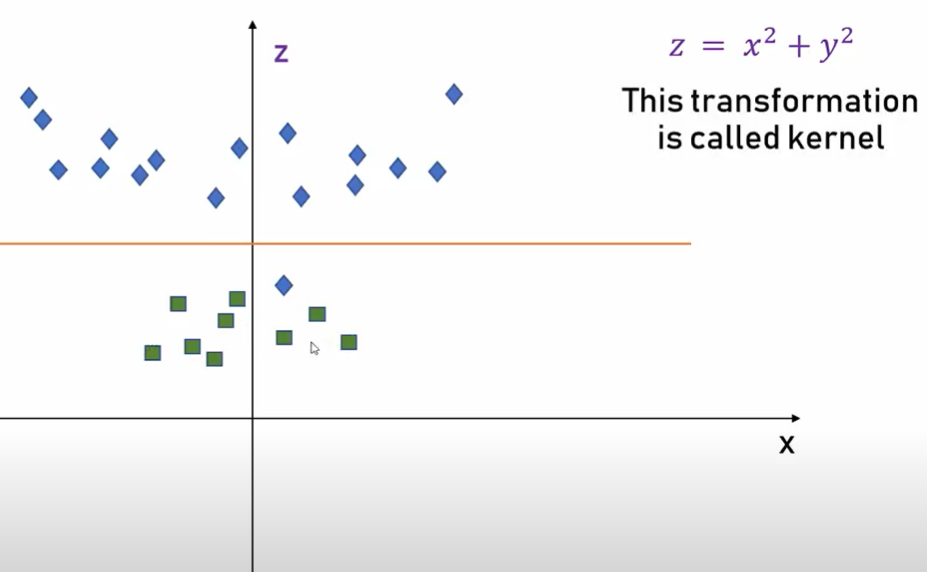

In [30]:
import pandas as pd
from sklearn.datasets import load_iris # load iris flower dataset
iris = load_iris()

In [31]:
dir(iris) # what all in the iris dataset, properties of the dataset

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [32]:
iris.feature_names # all the feature names of iris

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [33]:
#iris.data

In [34]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [35]:
iris.data_module

'sklearn.datasets.data'

In [36]:
len(iris.data)

150

In [37]:
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [38]:
df['target']=iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [39]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [40]:
df[df.target==0].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [41]:
df[df.target==1].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1


In [42]:
df[df.target==2].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


In [43]:
df['flower_name']=df.target.apply(lambda x:iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [44]:
df[45:55]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
45,4.8,3.0,1.4,0.3,0,setosa
46,5.1,3.8,1.6,0.2,0,setosa
47,4.6,3.2,1.4,0.2,0,setosa
48,5.3,3.7,1.5,0.2,0,setosa
49,5.0,3.3,1.4,0.2,0,setosa
50,7.0,3.2,4.7,1.4,1,versicolor
51,6.4,3.2,4.5,1.5,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor
53,5.5,2.3,4.0,1.3,1,versicolor
54,6.5,2.8,4.6,1.5,1,versicolor


In [45]:
df0=df[:50]
df1=df[50:100]
df2=df[100:]

In [46]:
import matplotlib.pyplot as plt
%matplotlib inline

### Sepal length vs Sepal Width (Setosa vs Versicolor) 

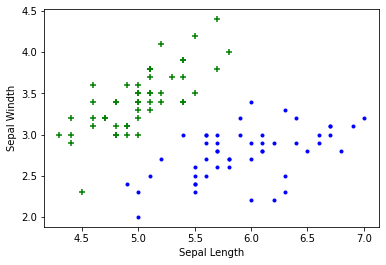

In [47]:
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Windth')
plt.scatter(df0['sepal length (cm)'],df0['sepal width (cm)'],color='green',marker='+')
plt.scatter(df1['sepal length (cm)'],df1['sepal width (cm)'],color='blue',marker='.')

### Petal length vs Pepal Width (Setosa vs Versicolor) 

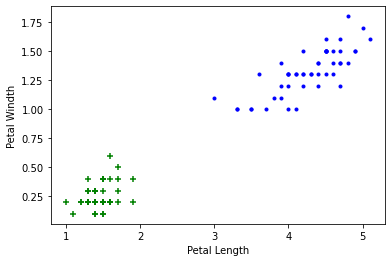

In [48]:
plt.xlabel('Petal Length')
plt.ylabel('Petal Windth')
plt.scatter(df0['petal length (cm)'],df0['petal width (cm)'],color='green',marker='+')
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],color='blue',marker='.')

### Train Using Support Vector Machine (SVM) 

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X = df.drop(['target','flower_name'], axis='columns')
y = df.target

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [52]:
len(X_train)

120

In [53]:
len(X_test)

30

In [54]:
from sklearn.svm import SVC
model = SVC()

In [55]:
model.fit(X_train, y_train)

SVC()

In [56]:
model.score(X_test, y_test)

0.9333333333333333

In [57]:
model.predict([[4.8,3.0,1.5,0.3]])

C:\Users\39762\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])